#Zomato Data Analysis Project Using Python
1. Project Objective:

The objective of this project is to analyze restaurant data to understand:

Online ordering trends

Table booking availability

Rating distribution

Cost trends

Restaurant category popularity

The goal is to extract business insights that help restaurant aggregators improve services and customer experience.




##Step 1: Importing necessary Python libraries.


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Step 2: Creating the data frame.


In [102]:
df = pd.read_csv("Zomato-data-.csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


##Step 3: Exploratory Data Analysis (EDA)
Data Cleaning And Preparation

###1. Getting summary of the dataset.






In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


###2. Getting Statistical summary of the dataset

In [104]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


###3. Shape - Number of rows & columns

In [105]:
df.shape

(148, 7)

###4. Checking for missing values

In [106]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


###5. Check Duplicate Value

In [107]:
df.duplicated().sum()

np.int64(0)

###6. Convert Rating Column

In [108]:
df['rate'] = df['rate'].str.split('/').str[0]
df['rate'] = df['rate'].astype(float)

#Step 4: Visualization of data

###1. Restaurant Type Distribution - Count Plot
Insight: Dining restaurants dominate the market

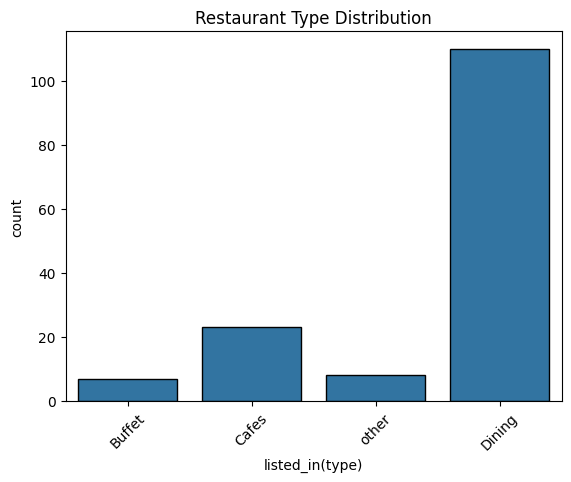

In [109]:
sns.countplot(x=df['listed_in(type)'] , edgecolor = "black")
plt.title("Restaurant Type Distribution")
plt.xticks(rotation=45)
plt.show()

###2. Online Order Availability -Count Plot
Insight: More restaurants do not offer online ordering compared to those that do.


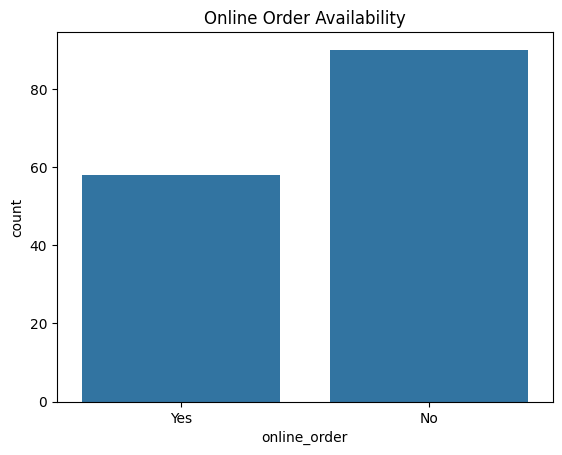

In [110]:
sns.countplot(x=df['online_order'])
plt.title("Online Order Availability")
plt.show()

###3. Table Booking Analysis - Count Plot
Insight: Very few restaurants provide table booking.

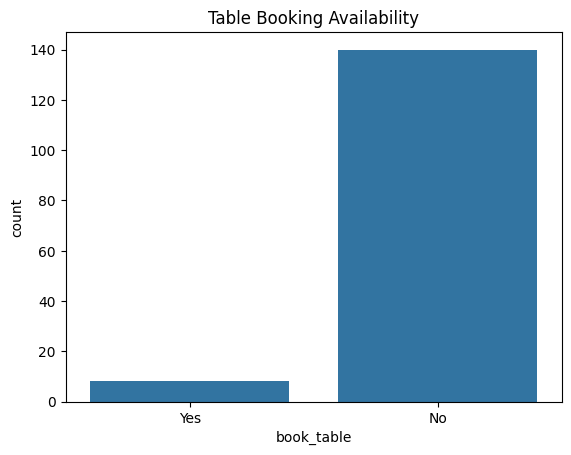

In [111]:
sns.countplot(x=df['book_table'])
plt.title("Table Booking Availability")
plt.show()

###4. Rating Distribution - Histogram
Insight: Most ratings fall between - 3.5 to 4.2


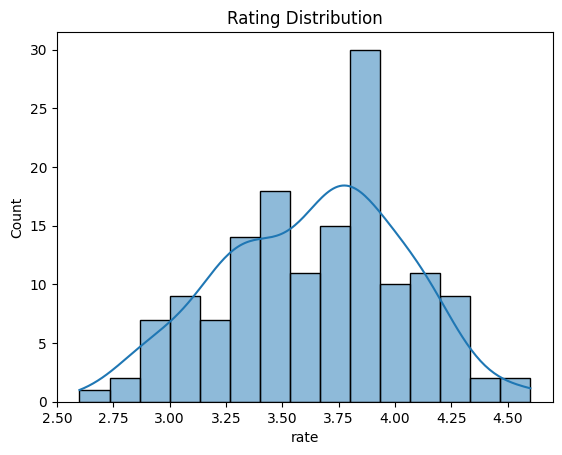

In [112]:
sns.histplot(df['rate'], bins=15, kde=True)
plt.title("Rating Distribution")
plt.show()

###5. Online Order vs Rating analysis - Box Plot
Insight: Restaurants offering online ordering tend to have slightly higher ratings, possibly due to increased accessibility and customer convenience.

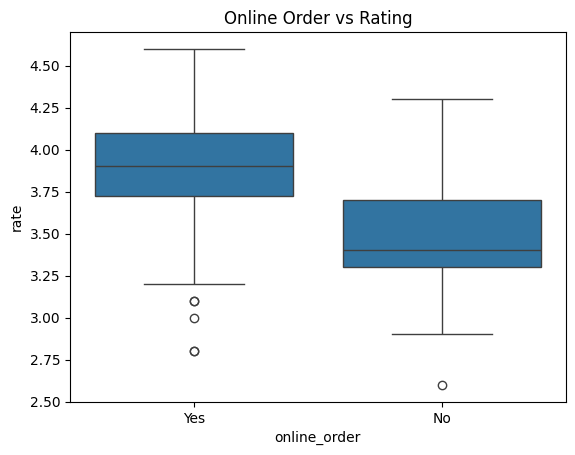

In [113]:
sns.boxplot(x='online_order', y='rate', data=df)

plt.title("Online Order vs Rating")

plt.show()

###6. Cost Distribution - Histogram
Insight: Most restaurants fall in the ₹200 to ₹600 price range.

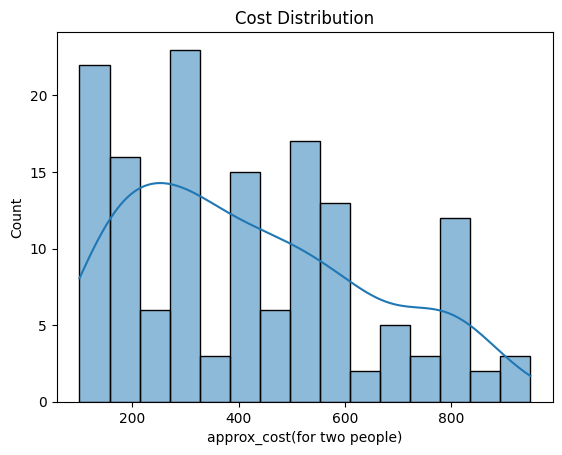

In [114]:
sns.histplot(df['approx_cost(for two people)'], bins=15, kde = True)
plt.title("Cost Distribution")
plt.show()

###7. Cost vs Rating - Scatter Plot
Insight 1: Restaurants with higher cost do not always have higher ratings.
Insight 2: Most ratings lie between 3.3 to 4.2
This means most restaurants are moderately rated.

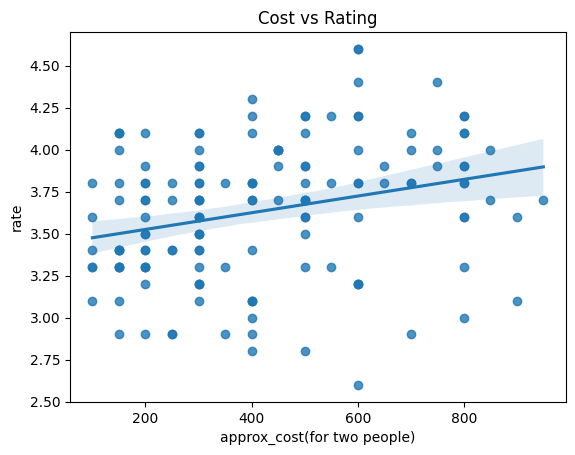

In [115]:
sns.regplot(x='approx_cost(for two people)', y='rate', data=df)
plt.title("Cost vs Rating")
plt.show()

###8. Votes vs Rating - Scatter Plot
Insight: Restaurants with more votes tend to have slightly higher ratings.



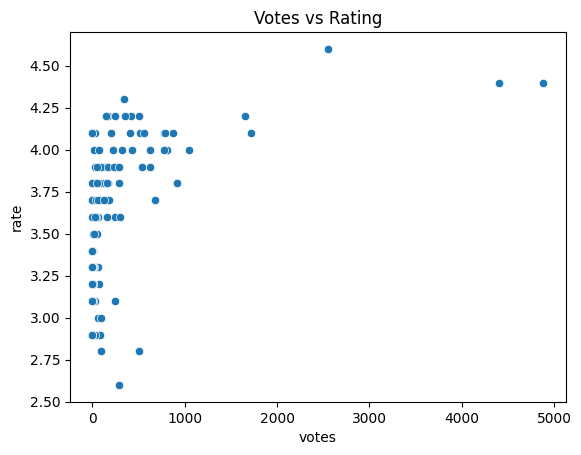

In [116]:
sns.scatterplot(x='votes', y='rate', data=df)
plt.title("Votes vs Rating")
plt.show()

###9. Correlation Heatmap
Insight:The heatmap shows relationships between:
Rating
Votes
Cost
Ratings are moderately tied to popularity, weakly tied to cost, and cost itself only weakly relates to popularity.

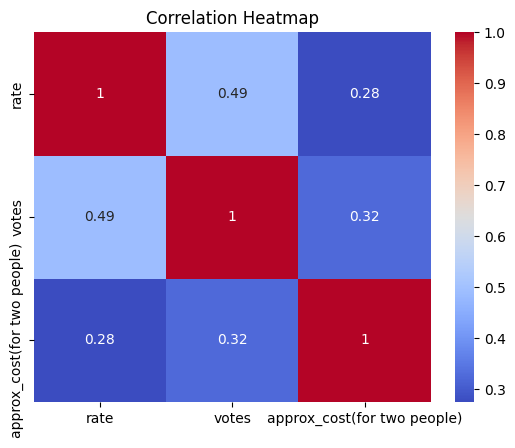

In [117]:
numeric_df = df.select_dtypes(include=['float','int'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#Key Insights from the Project:
1. Dining restaurants dominate the dataset, accounting for over 70% of establishments.

2. Online ordering is available in only 39% of restaurants, showing potential for digital expansion.

3. Table booking services are rare, with only a small percentage offering reservations.

4. Most restaurant ratings fall between 3.5 and 4.2, indicating generally positive customer satisfaction.

5. Average cost for two people is approximately ₹418, suggesting the majority of restaurants are mid-range.

6. Higher cost does not necessarily lead to higher ratings.

7. Restaurants with more customer votes tend to receive better ratings, indicating popularity influences perception.

